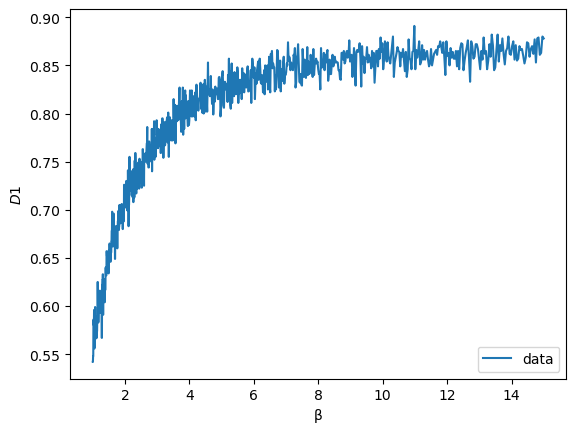

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("fractions_data_E0.csv")
beta_0=df['beta_0']
D1=df['D1']

plt.plot(beta_0, D1,label='data')
plt.xlabel("\u03B2")
plt.ylabel("$D1$")
plt.legend(loc='lower right')

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

[0.67158726] [[0.01908589]]


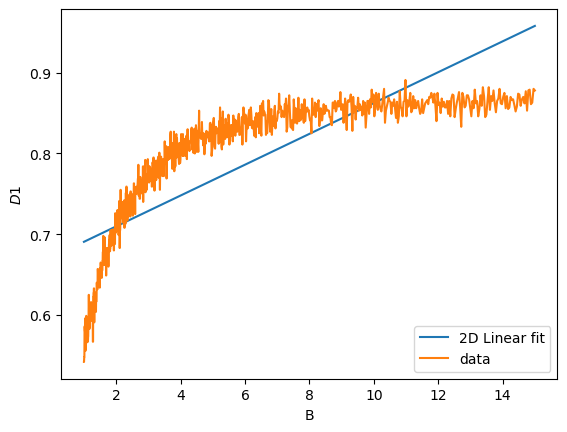

In [3]:
#Probar diferentes fittings
from sklearn.linear_model import LinearRegression
import numpy as np

lin_reg = LinearRegression()
lin_reg.fit(np.array(beta_0)[:, np.newaxis], np.array(D1)[:, np.newaxis])

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

y = theta0 + theta1[0] * beta_0

plt.plot(beta_0, y, label='2D Linear fit')
plt.plot(beta_0, D1,label='data')
plt.xlabel("B")
plt.ylabel("$D1$")
plt.legend(loc='lower right')


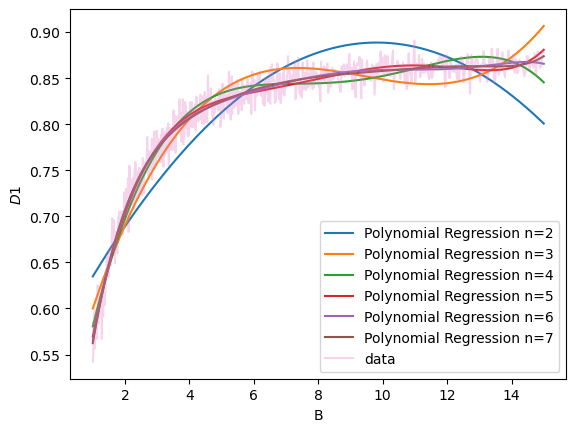

In [4]:
#explore polinomial regression
from astroML.linear_model import PolynomialRegression

beta = np.linspace(1, 15, 1000)
n = [2, 3, 4, 5, 6, 7 ] 

for i in n:
    model = PolynomialRegression(i)
    model.fit(np.array(beta_0)[:, np.newaxis], np.array(D1))
    D1_fit = model.predict(beta[:,np.newaxis])
    plt.plot(beta, D1_fit,label='Polynomial Regression n='+str(i))

plt.plot(beta_0, D1,label='data', alpha=0.3)
plt.xlabel("B")
plt.ylabel("$D1$")
plt.legend(loc='lower right')
#print(regressor.coef_)

#6 seems to be the best

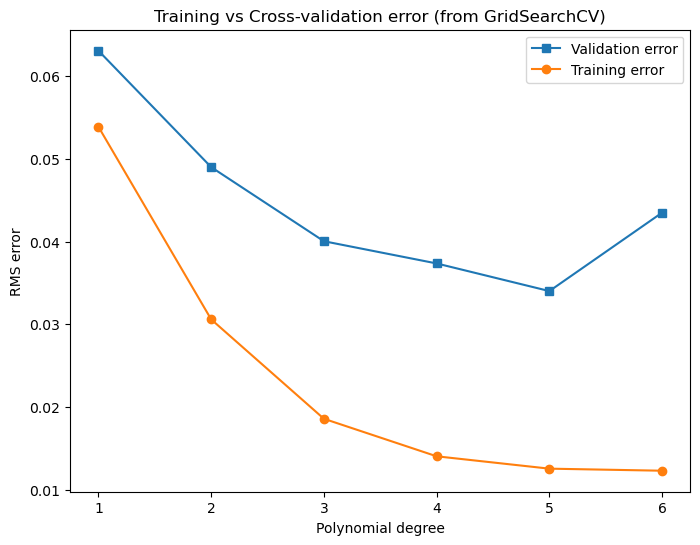

Best degree: 5


In [6]:
# Preparar el modelo y el grid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

model = make_pipeline(PolynomialFeatures(), LinearRegression())
grid = GridSearchCV(model, {'polynomialfeatures__degree': np.arange(1, 7)}, cv=10, scoring='neg_root_mean_squared_error', return_train_score=True)
grid.fit(np.array(beta_0)[:,np.newaxis], np.array(D1))

train_error = -grid.cv_results_['mean_train_score']
val_error = -grid.cv_results_['mean_test_score']

plt.figure(figsize=(8,6))
plt.plot(np.arange(1, 7), val_error, label='Validation error', marker='s')
plt.plot(np.arange(1, 7), train_error, label='Training error', marker='o')
plt.xlabel('Polynomial degree')
plt.ylabel('RMS error')
plt.title('Training vs Cross-validation error (from GridSearchCV)')
plt.legend()
#plt.ylim(0.8,2)
plt.show()
print("Best degree:", grid.best_params_['polynomialfeatures__degree'])

In [7]:
# i will say im underfitting from o to 5, ans then from 6 and so on Im overfiting bc im leaning more but the validation set show big errors.

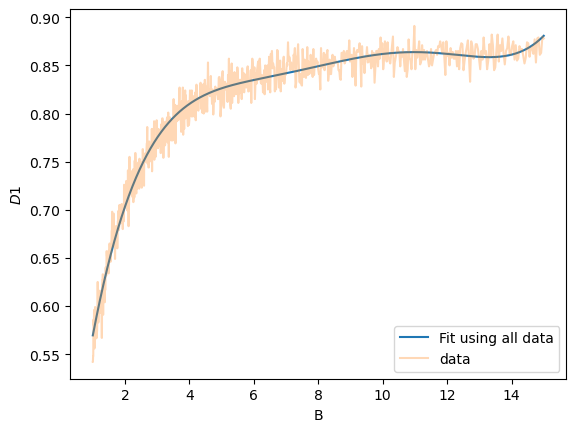

In [8]:
#lets ee how does the best fit looks like for polim.

classifier = PolynomialRegression(5)

classifier.fit(np.array(beta_0)[:,np.newaxis], np.array(D1)) # in this case dy is irrelevant because errors are homoscedastic
D1_fit = classifier.predict(beta[:,np.newaxis])

plt.plot(beta, D1_fit, label='Fit using all data')

plt.plot(beta_0, D1,label='data', alpha=0.3)
plt.xlabel("B")
plt.ylabel("$D1$")
plt.legend(loc='lower right')


#may you add learning curves? yes

In [9]:
coef=classifier.coef_


def modelo_pol(x):
    y=0
    for i, c in enumerate(coef.flatten()):
        y += c * x**(i)
    return y

In [19]:
with open('4.0e6_0.1AU_1_t1_1.000_t2_1.500_data_summary.txt', 'r') as f:
    lines = f.readlines()

betas = []

for line in lines:
    parts = line.strip().split()

    # Saltar líneas vacías o de texto (cabecera)
    if len(parts) < 3:
        continue

    try:
        # Tercer valor es Beta (índice 2 porque empieza en 0)
        beta = float(parts[2])
        betas.append(beta)
    except ValueError:
        # Si no se puede convertir a número (por ejemplo en líneas de texto), la salta
        continue

In [17]:
#este queda invalido.
betas = np.array(betas)

probabilidades = np.array([modelo_pol(x) for x in betas])

indices_sobreviven = np.random.rand(len(betas)) < probabilidades

beta_filtrado = betas[indices_sobreviven]

with open("beta_filtrado.csv", "w", encoding="utf-8") as f:
    f.write("beta_filtrado\n") 
    for valor in beta_filtrado:
        f.write(f"{str(valor).replace('.', ',')}\n")

In [21]:
import pandas as pd
import numpy as np

betas = np.array(betas)           
probabilidades = np.array([modelo_pol(x) for x in betas])
indices_sobreviven = np.random.rand(len(betas)) < probabilidades
beta_filtrado = betas[indices_sobreviven]

df = pd.DataFrame({'beta_filtrado': beta_filtrado})
df.to_excel('beta_filtrado.xlsx', index=False, engine='openpyxl')